# Day Trading Analysis Notebook

This notebook performs a fully automated analysis of a MetaTrader-style day trading CSV export.

Expected Colab upload filename: **`day_1.csv`**

It will generate:

- clean closed-fills and aggregated closing-order event CSVs
- summary, risk, symbol, hourly, side, and trade-quality stats
- equity curve, drawdown, P&L distribution, symbol/hour charts, and more
- a self-contained HTML report
- a ZIP bundle containing all outputs


## 1. Setup

Run all cells from top to bottom. In Google Colab, upload `day_1.csv` when prompted, or place it in the working directory first.


In [ ]:
# =========================
# Configuration
# =========================

FILE_NAME = "/content/trades0625a.csv"        # Colab upload name expected by default
OUTPUT_DIR = "day_trading_analysis_output"
ASSET_DIR = f"{OUTPUT_DIR}/assets"
CURRENCY_SYMBOL = ""           # Example: "$", "€", "£"; keep blank if broker export currency is implicit
INITIAL_EQUITY = None          # Optional. Example: 10000. If set, return % and DD % will be calculated.

# Behaviour
AGGREGATE_BY_CLOSING_ORDER = True  # Treat multiple fills under the same closing order as one exit event.
INCLUDE_COMMISSION_FEE_SWAP = True  # Net P&L = Profit + Commission + Fee + Swap when available.

# Chart settings
FIG_DPI = 160
FIGSIZE_WIDE = (12, 5.8)
FIGSIZE_TALL = (10, 6)
TOP_N_TABLES = 10

In [ ]:
# =========================
# Imports
# =========================

import os
import re
import math
import json
import base64
import zipfile
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(ASSET_DIR).mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [ ]:
# =========================
# Load CSV
# =========================

def running_in_colab() -> bool:
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

if not os.path.exists(FILE_NAME):
    if running_in_colab():
        from google.colab import files
        print(f"{FILE_NAME} was not found in the current Colab directory.")
        print("Upload your broker CSV now. The notebook expects day_1.csv, but it can use another uploaded CSV if needed.")
        uploaded = files.upload()
        if FILE_NAME not in uploaded:
            csv_candidates = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
            if not csv_candidates:
                raise FileNotFoundError("No CSV file was uploaded.")
            FILE_NAME = csv_candidates[0]
            print(f"Using uploaded file: {FILE_NAME}")
    else:
        raise FileNotFoundError(f"Could not find {FILE_NAME}. Put the CSV next to this notebook or change FILE_NAME.")

raw = pd.read_csv(FILE_NAME, dtype=str, encoding="utf-8-sig")
raw.columns = [str(c).strip() for c in raw.columns]

print(f"Loaded {len(raw):,} rows from {FILE_NAME}")
display(raw.head())
display(pd.DataFrame({"column": raw.columns}))

Loaded 3,134 rows from /content/trades0625a.csv


,Time,Deal,Symbol,Type,Direction,Volume,Price,Order,Commission,Fee,Swap,Profit
0,2026.06.22 00:19:38,5881,XAUUSD,buy,in,0.22,4 155.710,4643,0.00,0.00,0.00,0.00
1,2026.06.22 00:19:38,5882,XAUUSD,buy,in,0.33,4 155.710,4644,0.00,0.00,0.00,0.00
2,2026.06.22 00:19:48,5886,XAUUSD,sell,out,0.55,4 154.705,4731,0.00,0.00,0.00,-55.27
3,2026.06.22 00:22:54,5981,XAUUSD,sell,in,0.18,4 157.825,4789,0.00,0.00,0.00,0.00
4,2026.06.22 00:22:54,5982,XAUUSD,sell,in,0.28,4 157.825,4790,0.00,0.00,0.00,0.00


,column
0,Time
1,Deal
2,Symbol
3,Type
4,Direction
5,Volume
6,Price
7,Order
8,Commission
9,Fee


In [ ]:
# =========================
# Helpers
# =========================

def find_col(df: pd.DataFrame, aliases, required=True):
    """Find a column by case-insensitive aliases."""
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for alias in aliases:
        key = alias.strip().lower()
        if key in lower_map:
            return lower_map[key]
    # fuzzy: remove spaces/underscores
    norm_map = {re.sub(r"[\s_]+", "", str(c).strip().lower()): c for c in df.columns}
    for alias in aliases:
        key = re.sub(r"[\s_]+", "", alias.strip().lower())
        if key in norm_map:
            return norm_map[key]
    if required:
        raise KeyError(f"Could not find required column. Tried aliases: {aliases}. Available columns: {list(df.columns)}")
    return None

def clean_number(x):
    """
    Convert broker-formatted numeric strings to floats.
    Handles examples like:
    - '4 155.710' -> 4155.710
    - '- 55.27' -> -55.27
    - ' 1.32162' -> 1.32162
    - '0.00' -> 0
    """
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "":
        return np.nan
    s = s.replace("\u00a0", " ")
    s = s.replace("−", "-")
    s = re.sub(r"\s+", "", s)
    # If both comma and dot exist, assume comma is thousands separator.
    if "," in s and "." in s:
        s = s.replace(",", "")
    # If only comma exists, assume it might be a decimal comma.
    elif "," in s and "." not in s:
        s = s.replace(",", ".")
    s = re.sub(r"[^0-9.\-+eE]", "", s)
    if s in {"", "-", "+", ".", "-.", "+."}:
        return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

def clean_id(x):
    if pd.isna(x):
        return ""
    s = str(x).strip().replace("\u00a0", " ")
    s = re.sub(r"\s+", "", s)
    # Avoid turning IDs into floats if possible.
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]
    return s

def safe_div(num, den):
    if den is None or den == 0 or pd.isna(den):
        return np.nan
    return num / den

def money(x, currency=CURRENCY_SYMBOL):
    if pd.isna(x):
        return "n/a"
    return f"{currency}{x:,.2f}"

def pct(x):
    if pd.isna(x):
        return "n/a"
    return f"{x:.2%}"

def pct_points(x):
    if pd.isna(x):
        return "n/a"
    return f"{x:.1f}%"

def weighted_avg(values, weights):
    values = pd.Series(values).astype(float)
    weights = pd.Series(weights).astype(float).abs()
    mask = values.notna() & weights.notna()
    if not mask.any() or weights[mask].sum() == 0:
        return values[mask].mean() if mask.any() else np.nan
    return np.average(values[mask], weights=weights[mask])

def max_streak(sign_series, target):
    max_s = cur = 0
    for v in sign_series:
        if v == target:
            cur += 1
            max_s = max(max_s, cur)
        else:
            cur = 0
    return max_s

def signed_label(pnl):
    if pnl > 0:
        return "Win"
    if pnl < 0:
        return "Loss"
    return "Breakeven"

def side_from_closing_type(close_type):
    """
    MetaTrader convention:
    - A closing sell usually closes a long/buy position.
    - A closing buy usually closes a short/sell position.
    """
    t = str(close_type).strip().lower()
    if t == "sell":
        return "Long position closed"
    if t == "buy":
        return "Short position closed"
    return "Unknown"

In [ ]:
# =========================
# Clean and prepare deals
# =========================

COL_TIME = find_col(raw, ["Time", "Open Time", "Close Time", "Date"])
COL_DEAL = find_col(raw, ["Deal", "Deal ID", "Ticket"], required=False)
COL_SYMBOL = find_col(raw, ["Symbol", "Instrument"])
COL_TYPE = find_col(raw, ["Type", "Deal Type"])
COL_DIRECTION = find_col(raw, ["Direction", "Entry"])
COL_VOLUME = find_col(raw, ["Volume", "Lots", "Size"])
COL_PRICE = find_col(raw, ["Price"])
COL_ORDER = find_col(raw, ["Order", "Order ID"], required=False)
COL_COMMISSION = find_col(raw, ["Commission"], required=False)
COL_FEE = find_col(raw, ["Fee"], required=False)
COL_SWAP = find_col(raw, ["Swap"], required=False)
COL_PROFIT = find_col(raw, ["Profit", "P/L", "PnL", "P&L"])

deals = raw.copy()

deals["time"] = pd.to_datetime(deals[COL_TIME], errors="coerce", format="%Y.%m.%d %H:%M:%S")
if deals["time"].isna().all():
    deals["time"] = pd.to_datetime(deals[COL_TIME], errors="coerce")

deals["deal_id"] = deals[COL_DEAL].map(clean_id) if COL_DEAL else deals.index.astype(str)
deals["symbol"] = deals[COL_SYMBOL].astype(str).str.strip()
deals["deal_type"] = deals[COL_TYPE].astype(str).str.strip().str.lower()
deals["direction"] = deals[COL_DIRECTION].astype(str).str.strip().str.lower()
deals["volume"] = deals[COL_VOLUME].map(clean_number)
deals["price"] = deals[COL_PRICE].map(clean_number)
deals["order_id"] = deals[COL_ORDER].map(clean_id) if COL_ORDER else deals["deal_id"]

for source_col, clean_col in [
    (COL_PROFIT, "profit"),
    (COL_COMMISSION, "commission"),
    (COL_FEE, "fee"),
    (COL_SWAP, "swap"),
]:
    if source_col:
        deals[clean_col] = deals[source_col].map(clean_number).fillna(0.0)
    else:
        deals[clean_col] = 0.0

if INCLUDE_COMMISSION_FEE_SWAP:
    deals["net_pnl"] = deals["profit"] + deals["commission"] + deals["fee"] + deals["swap"]
else:
    deals["net_pnl"] = deals["profit"]

deals = deals.sort_values(["time", "deal_id"], na_position="last").reset_index(drop=True)

closing_directions = {"out", "in/out", "out by", "out_by", "close", "closed"}
closed_fills = deals[deals["direction"].isin(closing_directions)].copy()

# Fallback: if no Direction-based closing rows are found, use non-zero P&L rows.
if closed_fills.empty:
    print("No closing rows found via Direction. Falling back to rows with non-zero net P&L.")
    closed_fills = deals[deals["net_pnl"].abs() > 1e-12].copy()

closed_fills["position_side"] = closed_fills["deal_type"].map(side_from_closing_type)
closed_fills["hour"] = closed_fills["time"].dt.hour
closed_fills["date"] = closed_fills["time"].dt.date
closed_fills["result"] = closed_fills["net_pnl"].map(signed_label)

print(f"Raw rows: {len(deals):,}")
print(f"Closed fills: {len(closed_fills):,}")
print(f"Symbols: {', '.join(sorted(deals['symbol'].dropna().unique()))}")

display(closed_fills.head())

Raw rows: 3,134
Closed fills: 1,370
Symbols: EURCHF, EURGBP, EURUSD, GBPUSD, USDCAD, XAGUSD, XAUUSD


,Time,Deal,Symbol,Type,Direction,Volume,Price,Order,Commission,Fee,Swap,Profit,time,deal_id,symbol,deal_type,direction,volume,price,order_id,profit,commission,fee,swap,net_pnl,position_side,hour,date,result
2,2026.06.22 00:19:48,5886,XAUUSD,sell,out,0.55,4 154.705,4731,0.00,0.00,0.00,-55.27,2026-06-22 00:19:48,5886,XAUUSD,sell,out,0.55,"4,154.70",4731,-55.27,0.00,0.00,0.00,-55.27,Long position closed,0,2026-06-22,Loss
5,2026.06.22 00:22:59,5988,XAUUSD,buy,out,0.46,4 158.615,4811,0.00,0.00,0.00,-36.34,2026-06-22 00:22:59,5988,XAUUSD,buy,out,0.46,"4,158.61",4811,-36.34,0.00,0.00,0.00,-36.34,Short position closed,0,2026-06-22,Loss
10,2026.06.22 01:55:49,10445,GBPUSD,buy,out,1,1.32188,7951,0.00,0.00,0.00,-26.73,2026-06-22 01:55:49,10445,GBPUSD,buy,out,1.00,1.32,7951,-26.73,0.00,0.00,0.00,-26.73,Short position closed,1,2026-06-22,Loss
11,2026.06.22 01:55:49,10446,GBPUSD,buy,out,2.64,1.32189,7951,0.00,0.00,0.00,-73.19,2026-06-22 01:55:49,10446,GBPUSD,buy,out,2.64,1.32,7951,-73.19,0.00,0.00,0.00,-73.19,Short position closed,1,2026-06-22,Loss
18,2026.06.22 02:00:03,10576,EURCHF,buy,out,1,0.92628,8025,0.00,0.00,0.00,42.09,2026-06-22 02:00:03,10576,EURCHF,buy,out,1.00,0.93,8025,42.09,0.00,0.00,0.00,42.09,Short position closed,2,2026-06-22,Win


In [ ]:
# =========================
# Aggregate multiple fills into clean closing-order events
# =========================

def aggregate_exit_events(closed: pd.DataFrame) -> pd.DataFrame:
    if closed.empty:
        return closed.copy()

    group_cols = ["order_id", "symbol", "deal_type", "direction"] if AGGREGATE_BY_CLOSING_ORDER else ["deal_id"]

    rows = []
    for group_key, g in closed.groupby(group_cols, dropna=False, sort=False):
        row = {
            "event_id": "|".join(map(str, group_key)) if isinstance(group_key, tuple) else str(group_key),
            "close_time": g["time"].max(),
            "first_fill_time": g["time"].min(),
            "symbol": g["symbol"].iloc[0],
            "closing_type": g["deal_type"].iloc[0],
            "direction": g["direction"].iloc[0],
            "position_side": g["position_side"].iloc[0],
            "fills": len(g),
            "volume": g["volume"].sum(),
            "avg_close_price": weighted_avg(g["price"], g["volume"]),
            "profit": g["profit"].sum(),
            "commission": g["commission"].sum(),
            "fee": g["fee"].sum(),
            "swap": g["swap"].sum(),
            "net_pnl": g["net_pnl"].sum(),
            "deal_ids": ", ".join(g["deal_id"].astype(str).tolist()),
            "order_ids": ", ".join(sorted(set(g["order_id"].astype(str).tolist()))),
        }
        rows.append(row)

    events = pd.DataFrame(rows)
    events = events.sort_values(["close_time", "event_id"], na_position="last").reset_index(drop=True)
    events["event_no"] = np.arange(1, len(events) + 1)
    events["hour"] = events["close_time"].dt.hour
    events["date"] = events["close_time"].dt.date
    events["result"] = events["net_pnl"].map(signed_label)
    events["cum_pnl"] = events["net_pnl"].cumsum()
    events["running_peak"] = np.maximum.accumulate(np.r_[0, events["cum_pnl"].values])[1:]
    events["drawdown"] = events["cum_pnl"] - events["running_peak"]
    events["is_win"] = events["net_pnl"] > 0
    events["is_loss"] = events["net_pnl"] < 0
    events["is_breakeven"] = events["net_pnl"] == 0
    return events

exit_events = aggregate_exit_events(closed_fills)

print(f"Closing-order events: {len(exit_events):,}")
display(exit_events.head())
display(exit_events.tail())

Closing-order events: 1,280


,event_id,close_time,first_fill_time,symbol,closing_type,direction,position_side,fills,volume,avg_close_price,profit,commission,fee,swap,net_pnl,deal_ids,order_ids,event_no,hour,date,result,cum_pnl,running_peak,drawdown,is_win,is_loss,is_breakeven
0,4731|XAUUSD|sell|out,2026-06-22 00:19:48,2026-06-22 00:19:48,XAUUSD,sell,out,Long position closed,1,0.55,"4,154.70",-55.27,0.00,0.00,0.00,-55.27,5886,4731,1,0,2026-06-22,Loss,-55.27,0.00,-55.27,False,True,False
1,4811|XAUUSD|buy|out,2026-06-22 00:22:59,2026-06-22 00:22:59,XAUUSD,buy,out,Short position closed,1,0.46,"4,158.61",-36.34,0.00,0.00,0.00,-36.34,5988,4811,2,0,2026-06-22,Loss,-91.61,0.00,-91.61,False,True,False
2,7951|GBPUSD|buy|out,2026-06-22 01:55:49,2026-06-22 01:55:49,GBPUSD,buy,out,Short position closed,2,3.64,1.32,-99.92,0.00,0.00,0.00,-99.92,"10445, 10446",7951,3,1,2026-06-22,Loss,-191.53,0.00,-191.53,False,True,False
3,8025|EURCHF|buy|out,2026-06-22 02:00:03,2026-06-22 02:00:03,EURCHF,buy,out,Short position closed,2,1.02,0.93,42.86,0.00,0.00,0.00,42.86,"10576, 10577",8025,4,2,2026-06-22,Win,-148.67,0.00,-148.67,True,False,False
4,8296|USDCAD|sell|out,2026-06-22 02:21:44,2026-06-22 02:21:44,USDCAD,sell,out,Long position closed,2,1.04,1.42,24.87,0.00,0.00,0.00,24.87,"11414, 11415",8296,5,2,2026-06-22,Win,-123.80,0.00,-123.80,True,False,False


,event_id,close_time,first_fill_time,symbol,closing_type,direction,position_side,fills,volume,avg_close_price,profit,commission,fee,swap,net_pnl,deal_ids,order_ids,event_no,hour,date,result,cum_pnl,running_peak,drawdown,is_win,is_loss,is_breakeven
1275,968802|EURUSD|buy|out,2026-06-26 14:10:18,2026-06-26 14:10:18,EURUSD,buy,out,Short position closed,1,1.00,1.14,20.21,0.00,0.00,0.00,20.21,657916,968802,1276,14,2026-06-26,Win,"9,352.41","9,352.41",0.00,True,False,False
1276,968822|EURUSD|buy|out,2026-06-26 14:10:23,2026-06-26 14:10:23,EURUSD,buy,out,Short position closed,1,1.00,1.14,35.21,0.00,0.00,0.00,35.21,657941,968822,1277,14,2026-06-26,Win,"9,387.62","9,387.62",0.00,True,False,False
1277,969091|EURUSD|buy|out,2026-06-26 14:11:16,2026-06-26 14:11:16,EURUSD,buy,out,Short position closed,1,1.00,1.14,31.21,0.00,0.00,0.00,31.21,658166,969091,1278,14,2026-06-26,Win,"9,418.83","9,418.83",0.00,True,False,False
1278,969138|EURUSD|buy|out,2026-06-26 14:11:27,2026-06-26 14:11:27,EURUSD,buy,out,Short position closed,1,1.00,1.14,31.21,0.00,0.00,0.00,31.21,658220,969138,1279,14,2026-06-26,Win,"9,450.04","9,450.04",0.00,True,False,False
1279,969148|EURUSD|buy|out,2026-06-26 14:11:30,2026-06-26 14:11:30,EURUSD,buy,out,Short position closed,1,0.50,1.14,16.10,0.00,0.00,0.00,16.10,658230,969148,1280,14,2026-06-26,Win,"9,466.14","9,466.14",0.00,True,False,False


In [19]:
# =========================
# Full statistics
# =========================

def equity_drawdown(pnl_series: pd.Series):
    pnl = pd.Series(pnl_series).fillna(0.0).astype(float)
    equity = pnl.cumsum()
    equity_with_start = pd.Series([0.0] + equity.tolist())
    peak = equity_with_start.cummax()
    dd = equity_with_start - peak
    return equity, peak.iloc[1:].reset_index(drop=True), dd.iloc[1:].reset_index(drop=True), dd.min()

def calculate_stats(events: pd.DataFrame, raw_deals: pd.DataFrame, fills: pd.DataFrame) -> dict:
    pnl = events["net_pnl"].astype(float) if not events.empty else pd.Series(dtype=float)
    wins = pnl[pnl > 0]
    losses = pnl[pnl < 0]
    breakeven = pnl[pnl == 0]
    equity, peak, dd, max_dd = equity_drawdown(pnl)
    signs = pnl.map(lambda x: "W" if x > 0 else ("L" if x < 0 else "BE")).tolist()

    gross_profit = wins.sum()
    gross_loss = losses.sum()
    total_net = pnl.sum()
    n = len(pnl)

    peak_idx = int(equity.idxmax()) if len(equity) else None
    trough_idx = int(dd.idxmin()) if len(dd) else None
    largest_giveback_from_peak_to_close = (equity.max() - equity.iloc[-1]) if len(equity) else np.nan

    stats = {
        "source_file": FILE_NAME,
        "start_time": raw_deals["time"].min(),
        "end_time": raw_deals["time"].max(),
        "raw_rows": len(raw_deals),
        "closed_fills": len(fills),
        "closing_order_events": n,
        "symbols_traded": raw_deals["symbol"].nunique(),
        "symbols": ", ".join(sorted(raw_deals["symbol"].dropna().unique())),
        "total_volume_closed": fills["volume"].sum() if "volume" in fills else np.nan,
        "net_pnl": total_net,
        "gross_profit": gross_profit,
        "gross_loss": gross_loss,
        "profit_factor": safe_div(gross_profit, abs(gross_loss)),
        "win_count": len(wins),
        "loss_count": len(losses),
        "breakeven_count": len(breakeven),
        "win_rate": safe_div(len(wins), n),
        "loss_rate": safe_div(len(losses), n),
        "avg_trade": pnl.mean() if n else np.nan,
        "median_trade": pnl.median() if n else np.nan,
        "avg_win": wins.mean() if len(wins) else np.nan,
        "avg_loss": losses.mean() if len(losses) else np.nan,
        "median_win": wins.median() if len(wins) else np.nan,
        "median_loss": losses.median() if len(losses) else np.nan,
        "best_trade": pnl.max() if n else np.nan,
        "worst_trade": pnl.min() if n else np.nan,
        "payoff_ratio": safe_div(wins.mean() if len(wins) else np.nan, abs(losses.mean()) if len(losses) else np.nan),
        "expectancy": pnl.mean() if n else np.nan,
        "expectancy_per_closed_fill": safe_div(total_net, len(fills)),
        "std_trade": pnl.std(ddof=1) if n > 1 else np.nan,
        "trade_sharpe_like": safe_div(pnl.mean(), pnl.std(ddof=1)) * math.sqrt(n) if n > 1 and pnl.std(ddof=1) != 0 else np.nan,
        "max_drawdown": max_dd,
        "max_drawdown_pct_initial_equity": safe_div(max_dd, INITIAL_EQUITY) if INITIAL_EQUITY else np.nan,
        "recovery_factor": safe_div(total_net, abs(max_dd)),
        "largest_giveback_peak_to_close": largest_giveback_from_peak_to_close,
        "max_win_streak": max_streak(signs, "W"),
        "max_loss_streak": max_streak(signs, "L"),
        "peak_equity": equity.max() if len(equity) else np.nan,
        "final_equity_pnl": equity.iloc[-1] if len(equity) else np.nan,
        "peak_event_no": int(events.loc[peak_idx, "event_no"]) if peak_idx is not None and len(events) else None,
        "trough_event_no": int(events.loc[trough_idx, "event_no"]) if trough_idx is not None and len(events) else None,
    }

    if INITIAL_EQUITY:
        stats["return_on_initial_equity"] = total_net / INITIAL_EQUITY
        stats["ending_equity"] = INITIAL_EQUITY + total_net
    else:
        stats["return_on_initial_equity"] = np.nan
        stats["ending_equity"] = np.nan

    return stats

summary_stats = calculate_stats(exit_events, deals, closed_fills)

def stats_to_display(stats):
    rows = [
        ("Source file", stats["source_file"]),
        ("Time span", f"{stats['start_time']} → {stats['end_time']}"),
        ("Raw rows", f"{stats['raw_rows']:,}"),
        ("Closed fills", f"{stats['closed_fills']:,}"),
        ("Closing-order events", f"{stats['closing_order_events']:,}"),
        ("Symbols traded", f"{stats['symbols_traded']:,}: {stats['symbols']}"),
        ("Closed volume", f"{stats['total_volume_closed']:,.2f}"),
        ("Net P&L", money(stats["net_pnl"])),
        ("Gross profit", money(stats["gross_profit"])),
        ("Gross loss", money(stats["gross_loss"])),
        ("Profit factor", f"{stats['profit_factor']:.2f}" if pd.notna(stats["profit_factor"]) else "n/a"),
        ("Win rate", pct(stats["win_rate"])),
        ("Wins / Losses / Breakeven", f"{stats['win_count']} / {stats['loss_count']} / {stats['breakeven_count']}"),
        #("Average trade", money(stats["avg_trade"])),
        #("Median trade", money(stats["median_trade"])),
        #("Average winner", money(stats["avg_win"])),
        #("Average loser", money(stats["avg_loss"])),
        #("Payoff ratio", f"{stats['payoff_ratio']:.2f}" if pd.notna(stats["payoff_ratio"]) else "n/a"),
        #("Expectancy per event", money(stats["expectancy"])),
        #("Expectancy per closed fill", money(stats["expectancy_per_closed_fill"])),
        #("Best trade/event", money(stats["best_trade"])),
        #("Worst trade/event", money(stats["worst_trade"])),
        ("Std. dev. per event", money(stats["std_trade"])),
        ("Trade Sharpe-like", f"{stats['trade_sharpe_like']:.2f}" if pd.notna(stats["trade_sharpe_like"]) else "n/a"),
        ("Max drawdown", money(stats["max_drawdown"])),
        ("Recovery factor", f"{stats['recovery_factor']:.2f}" if pd.notna(stats["recovery_factor"]) else "n/a"),
        ("Peak P&L", money(stats["peak_equity"])),
        #("Largest giveback from peak to close", money(stats["largest_giveback_peak_to_close"])),
        #("Max win streak", f"{stats['max_win_streak']:,}"),
        #("Max loss streak", f"{stats['max_loss_streak']:,}"),
    ]
    if INITIAL_EQUITY:
        rows += [
            ("Initial equity", money(INITIAL_EQUITY)),
            ("Ending equity", money(stats["ending_equity"])),
            ("Return on initial equity", pct(stats["return_on_initial_equity"])),
            ("Max DD % of initial equity", pct(stats["max_drawdown_pct_initial_equity"])),
        ]
    return pd.DataFrame(rows, columns=["Metric", "Value"])

summary_display = stats_to_display(summary_stats)
display(summary_display)

,Metric,Value
0,Source file,/content/trades0625a.csv
1,Time span,2026-06-22 00:19:38 → 2026-06-26 14:11:30
2,Raw rows,"3,134"
3,Closed fills,"1,370"
4,Closing-order events,"1,280"
5,Symbols traded,"7: EURCHF, EURGBP, EURUSD, GBPUSD, USDCAD, XAG..."
6,Closed volume,"1,186.25"
7,Net P&L,"9,466.14"
8,Gross profit,"22,985.94"
9,Gross loss,"-13,519.80"


In [ ]:
# =========================
# Group statistics
# =========================

def group_stats(events: pd.DataFrame, group_col: str) -> pd.DataFrame:
    if events.empty:
        return pd.DataFrame()

    rows = []
    for key, g in events.groupby(group_col, dropna=False):
        pnl = g["net_pnl"].astype(float)
        wins = pnl[pnl > 0]
        losses = pnl[pnl < 0]
        gross_profit = wins.sum()
        gross_loss = losses.sum()
        rows.append({
            group_col: key,
            "events": len(g),
            "fills": g["fills"].sum() if "fills" in g else np.nan,
            "volume": g["volume"].sum() if "volume" in g else np.nan,
            "wins": len(wins),
            "losses": len(losses),
            "breakeven": (pnl == 0).sum(),
            "win_rate": safe_div(len(wins), len(g)),
            "net_pnl": pnl.sum(),
            "gross_profit": gross_profit,
            "gross_loss": gross_loss,
            "profit_factor": safe_div(gross_profit, abs(gross_loss)),
            "avg_event": pnl.mean(),
            "median_event": pnl.median(),
            "avg_win": wins.mean() if len(wins) else np.nan,
            "avg_loss": losses.mean() if len(losses) else np.nan,
            "best_event": pnl.max(),
            "worst_event": pnl.min(),
        })
    out = pd.DataFrame(rows).sort_values("net_pnl", ascending=False).reset_index(drop=True)
    return out

symbol_stats = group_stats(exit_events, "symbol")
hour_stats = group_stats(exit_events, "hour")
side_stats = group_stats(exit_events, "position_side")
type_stats = group_stats(exit_events, "closing_type")

# Add a 0-padded hour label for cleaner charts.
if not hour_stats.empty:
    hour_stats["hour_label"] = hour_stats["hour"].astype(int).map(lambda h: f"{h:02d}:00")
    hour_stats = hour_stats.sort_values("hour").reset_index(drop=True)

display(Markdown("### Symbol stats"))
display(symbol_stats)

display(Markdown("### Hour stats"))
display(hour_stats)

display(Markdown("### Position-side stats"))
display(side_stats)

display(Markdown("### Closing-type stats"))
display(type_stats)

### Symbol stats

,symbol,events,fills,volume,wins,losses,breakeven,win_rate,net_pnl,gross_profit,gross_loss,profit_factor,avg_event,median_event,avg_win,avg_loss,best_event,worst_event
0,XAUUSD,343,344,65.07,322,21,0,0.94,"3,834.22","8,781.95","-4,947.73",1.77,11.18,7.34,27.27,-235.61,"1,109.30",-553.17
1,EURUSD,272,283,203.51,254,18,0,0.93,"1,881.66","3,058.82","-1,177.16",2.60,6.92,4.16,12.04,-65.40,338.08,-618.30
2,EURGBP,297,306,210.74,282,14,1,0.95,"1,638.54","2,241.46",-602.92,3.72,5.52,2.71,7.95,-43.07,391.86,-372.61
3,XAGUSD,48,48,4.80,45,3,0,0.94,900.47,904.34,-3.87,233.68,18.76,13.88,20.10,-1.29,58.79,-1.85
4,USDCAD,153,189,404.05,137,15,1,0.90,735.22,"2,725.01","-1,989.79",1.37,4.81,1.69,19.89,-132.65,727.33,-393.61
5,EURCHF,14,22,51.35,10,4,0,0.71,525.44,985.45,-460.01,2.14,37.53,11.12,98.54,-115.00,338.24,-441.52
6,GBPUSD,153,178,246.73,133,20,0,0.87,-49.41,"4,288.91","-4,338.32",0.99,-0.32,8.60,32.25,-216.92,496.95,-398.68


### Hour stats

,hour,events,fills,volume,wins,losses,breakeven,win_rate,net_pnl,gross_profit,gross_loss,profit_factor,avg_event,median_event,avg_win,avg_loss,best_event,worst_event,hour_label
0,0,2,2,1.01,0,2,0,0.00,-91.61,0.00,-91.61,0.00,-45.81,-45.81,NaN,-45.81,-36.34,-55.27,00:00
1,1,1,2,3.64,0,1,0,0.00,-99.92,0.00,-99.92,0.00,-99.92,-99.92,NaN,-99.92,-99.92,-99.92,01:00
2,2,4,6,2.09,3,1,0,0.75,67.63,67.93,-0.30,226.43,16.91,12.54,22.64,-0.30,42.86,-0.30,02:00
3,3,21,21,10.59,19,2,0,0.90,66.41,68.61,-2.20,31.19,3.16,1.19,3.61,-1.10,26.43,-1.98,03:00
4,4,7,9,14.31,6,1,0,0.86,46.29,277.61,-231.32,1.20,6.61,5.58,46.27,-231.32,242.80,-231.32,04:00
5,5,26,27,16.06,24,2,0,0.92,-79.14,120.11,-199.25,0.60,-3.04,1.13,5.00,-99.62,26.70,-198.41,05:00
6,6,55,56,29.87,50,5,0,0.91,19.22,355.67,-336.45,1.06,0.35,2.57,7.11,-67.29,58.79,-183.14,06:00
7,7,139,145,105.69,136,3,0,0.98,456.41,"1,427.10",-970.69,1.47,3.28,4.13,10.49,-323.56,385.60,-398.68,07:00
8,8,101,106,69.43,96,5,0,0.95,273.46,888.25,-614.79,1.44,2.71,3.36,9.25,-122.96,217.34,-330.66,08:00
9,9,96,102,75.91,80,15,1,0.83,-714.90,881.93,"-1,596.83",0.55,-7.45,1.98,11.02,-106.46,233.00,-553.55,09:00


### Position-side stats

,position_side,events,fills,volume,wins,losses,breakeven,win_rate,net_pnl,gross_profit,gross_loss,profit_factor,avg_event,median_event,avg_win,avg_loss,best_event,worst_event
0,Short position closed,1157,1239,"1,057.24",1080,75,2,0.93,"14,388.78","21,791.65","-7,402.87",2.94,12.44,5.06,20.18,-98.70,"1,109.30",-618.30
1,Long position closed,123,131,129.01,103,20,0,0.84,"-4,922.64","1,194.29","-6,116.93",0.20,-40.02,3.18,11.60,-305.85,233.00,-553.17


### Closing-type stats

,closing_type,events,fills,volume,wins,losses,breakeven,win_rate,net_pnl,gross_profit,gross_loss,profit_factor,avg_event,median_event,avg_win,avg_loss,best_event,worst_event
0,buy,1157,1239,"1,057.24",1080,75,2,0.93,"14,388.78","21,791.65","-7,402.87",2.94,12.44,5.06,20.18,-98.70,"1,109.30",-618.30
1,sell,123,131,129.01,103,20,0,0.84,"-4,922.64","1,194.29","-6,116.93",0.20,-40.02,3.18,11.60,-305.85,233.00,-553.17


In [ ]:
# =========================
# Best/worst trades and diagnostic tables
# =========================

best_events = exit_events.sort_values("net_pnl", ascending=False).head(TOP_N_TABLES).copy()
worst_events = exit_events.sort_values("net_pnl", ascending=True).head(TOP_N_TABLES).copy()

display(Markdown(f"### Top {TOP_N_TABLES} best closing-order events"))
display(best_events[["event_no", "close_time", "symbol", "position_side", "volume", "avg_close_price", "fills", "net_pnl", "cum_pnl", "deal_ids"]])

display(Markdown(f"### Top {TOP_N_TABLES} worst closing-order events"))
display(worst_events[["event_no", "close_time", "symbol", "position_side", "volume", "avg_close_price", "fills", "net_pnl", "cum_pnl", "deal_ids"]])

# Optional sanity check: closed fills vs aggregated events
sanity = pd.DataFrame({
    "check": [
        "Closed fills net P&L",
        "Aggregated events net P&L",
        "Difference",
        "Closed fills count",
        "Aggregated event count",
    ],
    "value": [
        closed_fills["net_pnl"].sum(),
        exit_events["net_pnl"].sum(),
        closed_fills["net_pnl"].sum() - exit_events["net_pnl"].sum(),
        len(closed_fills),
        len(exit_events),
    ]
})
display(Markdown("### Reconciliation check"))
display(sanity)

### Top 10 best closing-order events

,event_no,close_time,symbol,position_side,volume,avg_close_price,fills,net_pnl,cum_pnl,deal_ids
118,119,2026-06-24 11:16:46,XAUUSD,Short position closed,3.00,"4,057.25",2,"1,109.30","-3,889.53","167432, 167433"
275,276,2026-06-25 13:30:42,USDCAD,Short position closed,11.50,1.42,3,727.33,"-1,774.45","393675, 393676, 393677"
32,33,2026-06-22 14:25:42,GBPUSD,Short position closed,5.45,1.33,2,496.95,"1,137.67","36382, 36383"
28,29,2026-06-22 14:00:21,EURGBP,Short position closed,6.36,0.86,2,391.86,669.62,"35363, 35364"
12,13,2026-06-22 07:20:30,GBPUSD,Short position closed,6.36,1.32,2,385.60,-50.95,"20781, 20782"
114,115,2026-06-24 11:02:17,XAUUSD,Short position closed,4.00,"4,061.49",1,346.40,"-4,842.46",165862
29,30,2026-06-22 14:00:46,EURCHF,Short position closed,5.45,0.93,2,338.24,"1,007.86","35381, 35382"
60,61,2026-06-23 13:20:26,EURUSD,Short position closed,6.36,1.14,2,338.08,-269.75,"91704, 91705"
38,39,2026-06-22 15:57:47,EURGBP,Short position closed,5.45,0.86,2,332.44,989.58,"40794, 40795"
33,34,2026-06-22 14:30:11,EURCHF,Short position closed,5.45,0.93,2,284.06,"1,421.73","36631, 36632"


### Top 10 worst closing-order events

,event_no,close_time,symbol,position_side,volume,avg_close_price,fills,net_pnl,cum_pnl,deal_ids
64,65,2026-06-23 14:41:38,EURUSD,Short position closed,10.90,1.14,2,-618.30,-565.16,"95086, 95087"
914,915,2026-06-26 09:09:15,EURUSD,Short position closed,5.50,1.14,2,-553.55,"3,530.11","606668, 606669"
107,108,2026-06-24 11:00:44,XAUUSD,Long position closed,1.00,"4,060.57",1,-553.17,"-2,525.54",165708
108,109,2026-06-24 11:00:44,XAUUSD,Long position closed,1.00,"4,060.60",1,-550.37,"-3,075.91",165712
103,104,2026-06-24 10:40:11,XAUUSD,Long position closed,1.00,"4,066.96",1,-511.00,"-1,030.41",163853
110,111,2026-06-24 11:00:46,XAUUSD,Long position closed,1.00,"4,061.37",1,-472.97,"-4,014.05",165724
109,110,2026-06-24 11:00:45,XAUUSD,Long position closed,1.00,"4,061.45",1,-465.17,"-3,541.08",165721
67,68,2026-06-23 15:23:40,EURCHF,Short position closed,10.91,0.92,2,-441.52,"-1,575.50","96651, 96652"
106,107,2026-06-24 10:49:38,XAUUSD,Short position closed,1.00,"4,069.99",1,-424.07,"-1,972.37",164748
46,47,2026-06-23 07:36:19,GBPUSD,Long position closed,9.54,1.32,2,-398.68,26.04,"79114, 79115"


### Reconciliation check

,check,value
0,Closed fills net P&L,"9,466.14"
1,Aggregated events net P&L,"9,466.14"
2,Difference,-0.00
3,Closed fills count,"1,370.00"
4,Aggregated event count,"1,280.00"


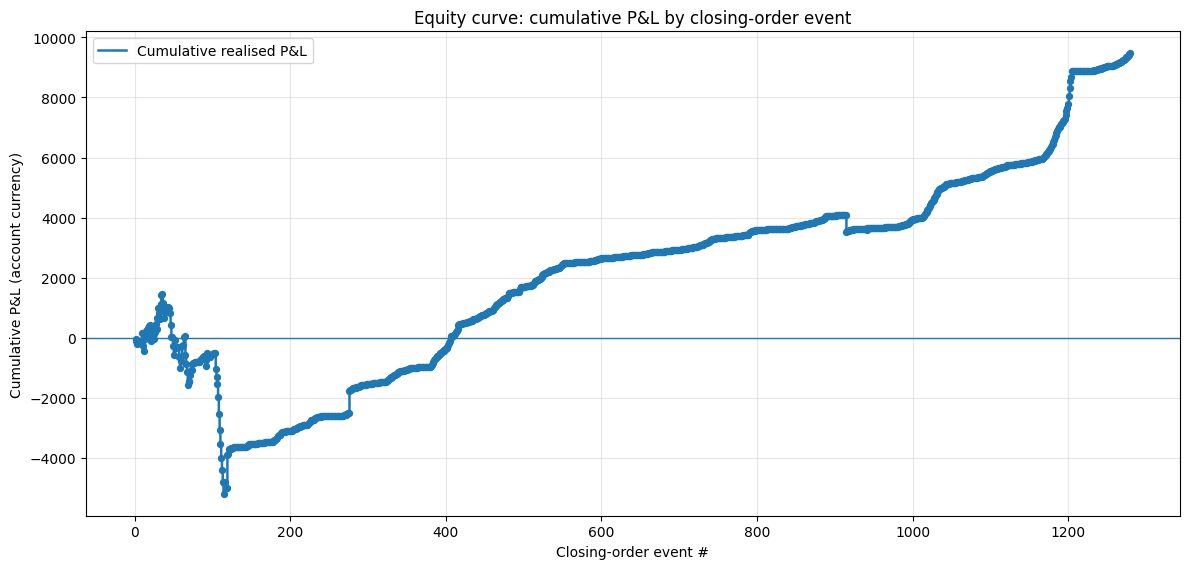

In [ ]:
# =========================
# Charts
# =========================

def savefig(name, tight=True):
    path = f"{ASSET_DIR}/{name}"
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()
    plt.close()
    return path

chart_paths = {}

if exit_events.empty:
    raise ValueError("No closing events available for charting.")

# 1. Equity curve - stepwise realised P&L
plt.figure(figsize=FIGSIZE_WIDE)

plt.step(
    exit_events["event_no"],
    exit_events["cum_pnl"],
    where="post",
    linewidth=1.8,
    label="Cumulative realised P&L"
)

# Optional: keep markers so each closing-order event is visible
plt.scatter(
    exit_events["event_no"],
    exit_events["cum_pnl"],
    s=18,
    zorder=3
)

plt.axhline(0, linewidth=1)
plt.title("Equity curve: cumulative P&L by closing-order event")
plt.xlabel("Closing-order event #")
plt.ylabel(f"Cumulative P&L ({CURRENCY_SYMBOL or 'account currency'})")
plt.grid(True, alpha=0.3)
plt.legend()

chart_paths["equity_curve"] = savefig("01_equity_curve.png")



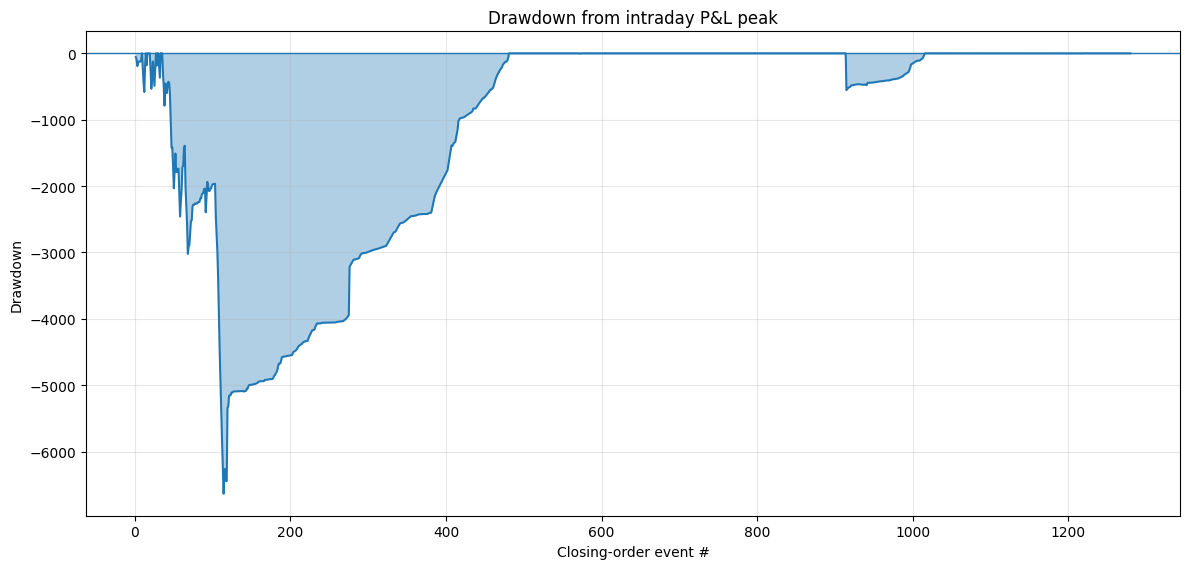

In [ ]:
# 2. Drawdown
plt.figure(figsize=FIGSIZE_WIDE)
plt.fill_between(exit_events["event_no"], exit_events["drawdown"], 0, alpha=0.35)
plt.plot(exit_events["event_no"], exit_events["drawdown"], linewidth=1.5)
plt.axhline(0, linewidth=1)
plt.title("Drawdown from intraday P&L peak")
plt.xlabel("Closing-order event #")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
chart_paths["drawdown"] = savefig("02_drawdown.png")


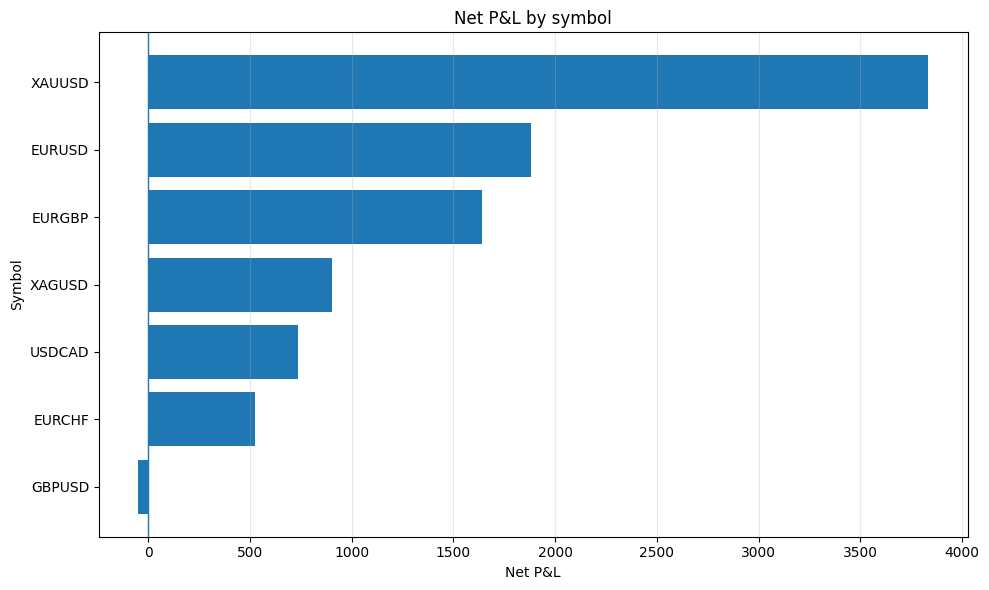

In [ ]:

# 3. P&L by symbol
sym_plot = symbol_stats.sort_values("net_pnl", ascending=True)
plt.figure(figsize=FIGSIZE_TALL)
plt.barh(sym_plot["symbol"].astype(str), sym_plot["net_pnl"])
plt.axvline(0, linewidth=1)
plt.title("Net P&L by symbol")
plt.xlabel("Net P&L")
plt.ylabel("Symbol")
plt.grid(axis="x", alpha=0.3)
chart_paths["pnl_by_symbol"] = savefig("03_pnl_by_symbol.png")



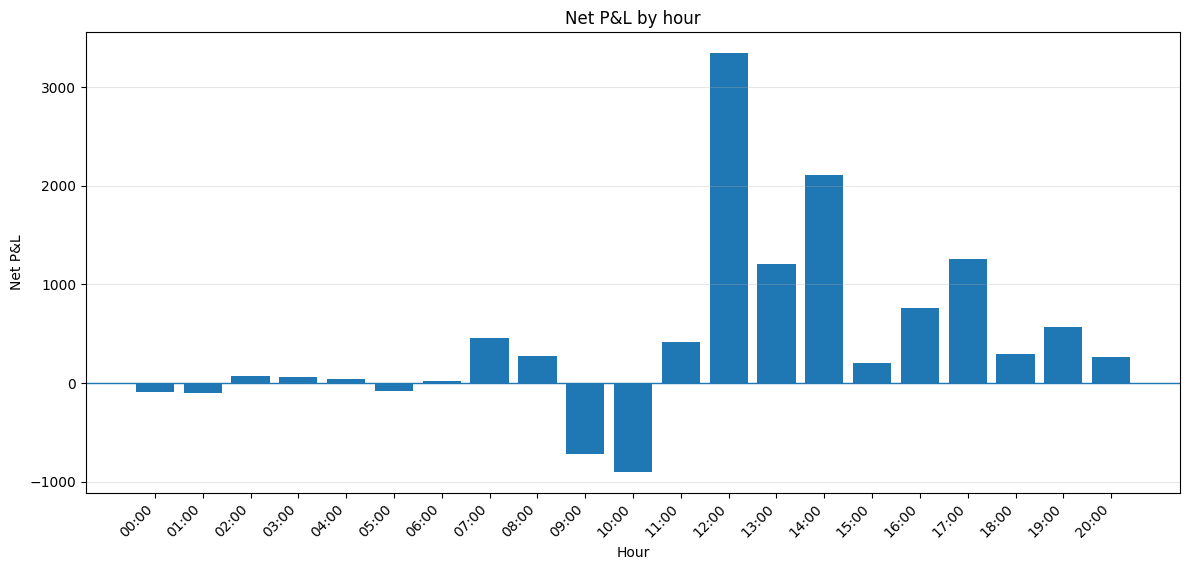

In [ ]:
# 4. P&L by hour
hour_plot = hour_stats.sort_values("hour")
plt.figure(figsize=FIGSIZE_WIDE)
plt.bar(hour_plot["hour_label"].astype(str), hour_plot["net_pnl"])
plt.axhline(0, linewidth=1)
plt.title("Net P&L by hour")
plt.xlabel("Hour")
plt.ylabel("Net P&L")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
chart_paths["pnl_by_hour"] = savefig("04_pnl_by_hour.png")



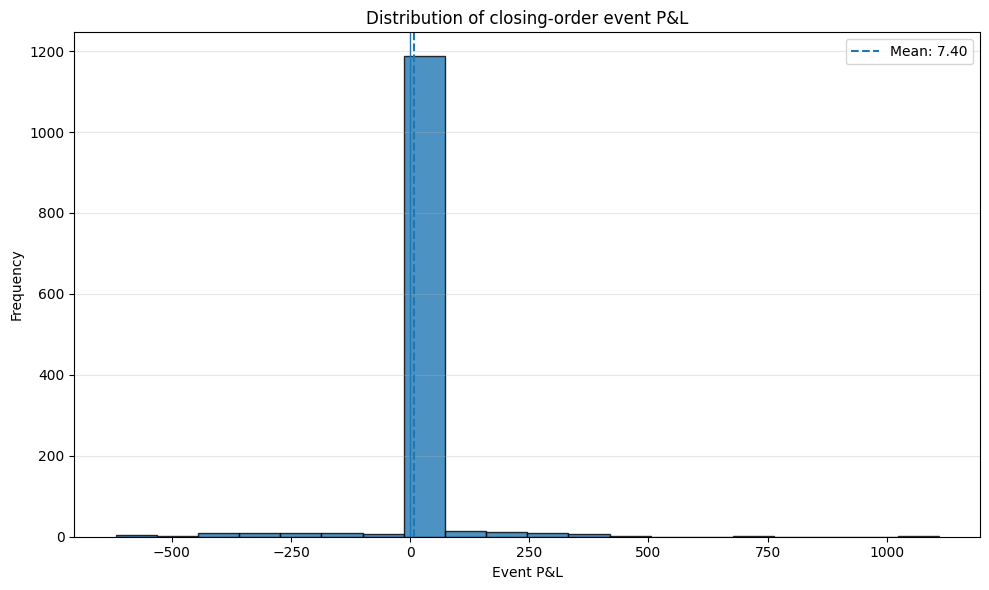

In [ ]:
# 5. P&L distribution
plt.figure(figsize=FIGSIZE_TALL)
plt.hist(exit_events["net_pnl"], bins=min(20, max(5, int(np.sqrt(len(exit_events))) + 3)), edgecolor="black", alpha=0.8)
plt.axvline(0, linewidth=1)
plt.axvline(exit_events["net_pnl"].mean(), linestyle="--", linewidth=1.5, label=f"Mean: {exit_events['net_pnl'].mean():.2f}")
plt.title("Distribution of closing-order event P&L")
plt.xlabel("Event P&L")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)
chart_paths["pnl_distribution"] = savefig("05_pnl_distribution.png")



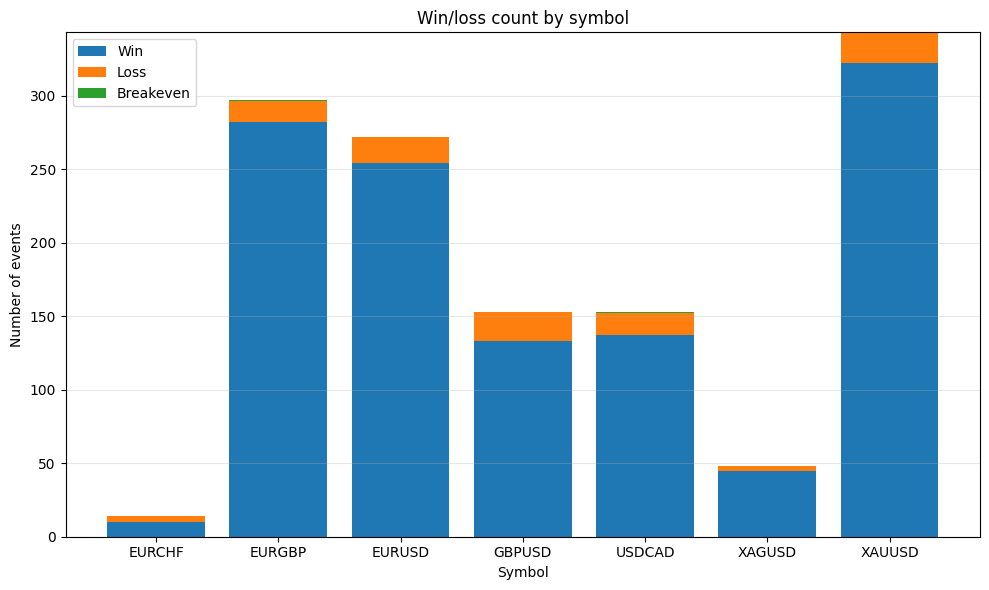

In [ ]:
# 6. Wins/losses by symbol
wl = exit_events.pivot_table(index="symbol", columns="result", values="event_id", aggfunc="count", fill_value=0)
for col in ["Win", "Loss", "Breakeven"]:
    if col not in wl.columns:
        wl[col] = 0
wl = wl[["Win", "Loss", "Breakeven"]].sort_index()
plt.figure(figsize=FIGSIZE_TALL)
bottom = np.zeros(len(wl))
for col in wl.columns:
    plt.bar(wl.index.astype(str), wl[col], bottom=bottom, label=col)
    bottom += wl[col].values
plt.title("Win/loss count by symbol")
plt.xlabel("Symbol")
plt.ylabel("Number of events")
plt.legend()
plt.grid(axis="y", alpha=0.3)
chart_paths["win_loss_by_symbol"] = savefig("06_win_loss_by_symbol.png")



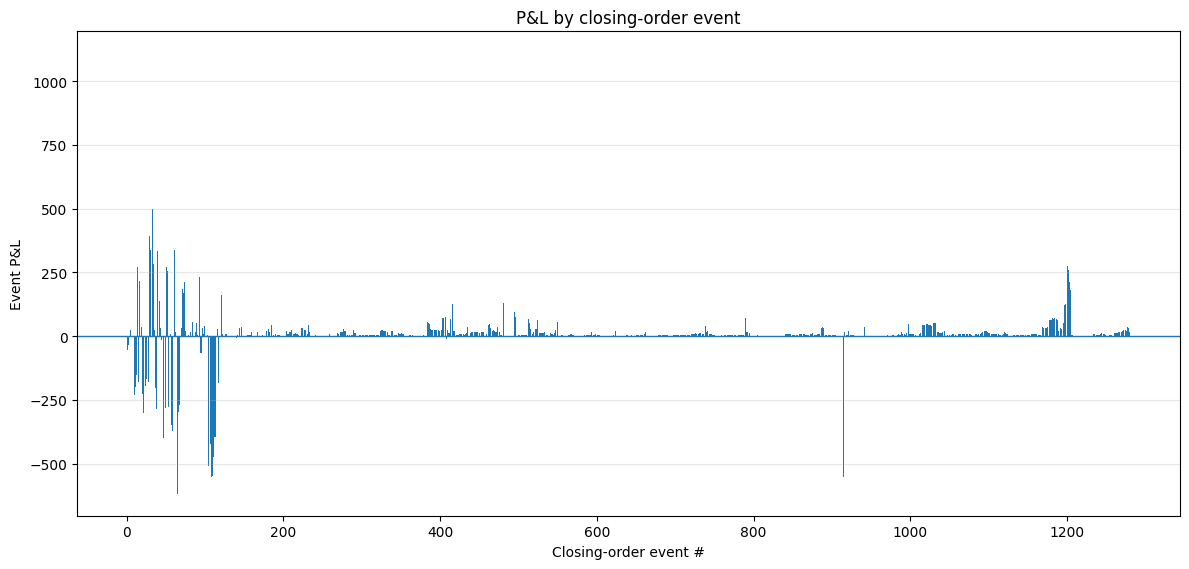

In [ ]:
# 7. Trade-by-trade event P&L
plt.figure(figsize=FIGSIZE_WIDE)
plt.bar(exit_events["event_no"], exit_events["net_pnl"])
plt.axhline(0, linewidth=1)
plt.title("P&L by closing-order event")
plt.xlabel("Closing-order event #")
plt.ylabel("Event P&L")
plt.grid(axis="y", alpha=0.3)
chart_paths["event_pnl_sequence"] = savefig("07_event_pnl_sequence.png")



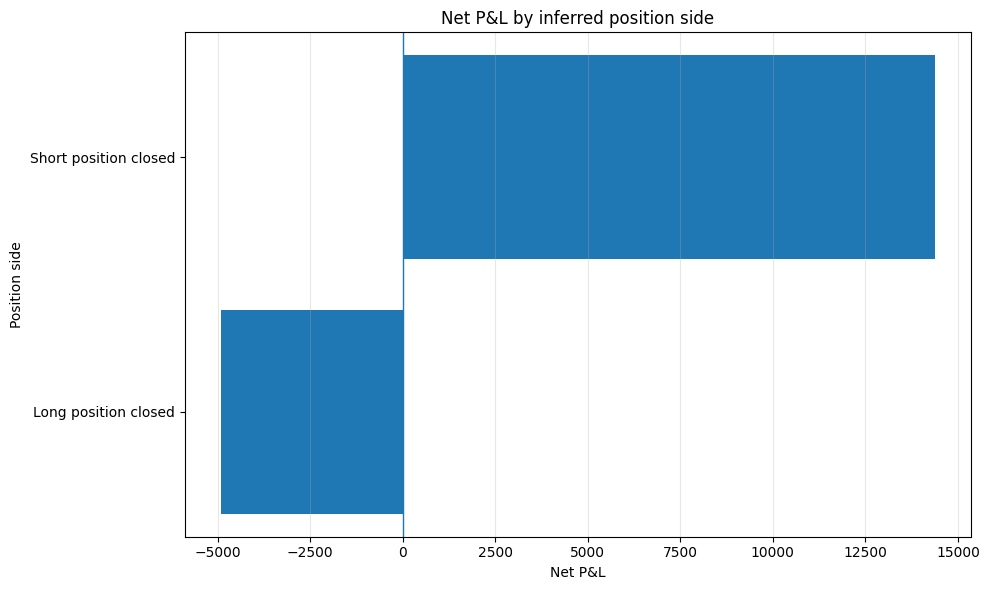

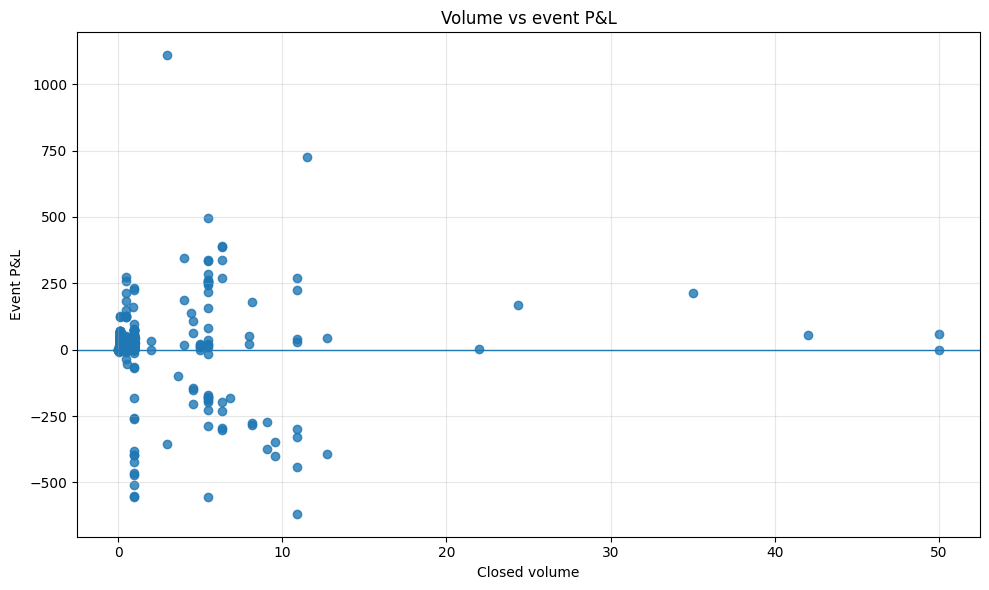

{'equity_curve': 'day_trading_analysis_output/assets/01_equity_curve.png',
 'drawdown': 'day_trading_analysis_output/assets/02_drawdown.png',
 'pnl_by_symbol': 'day_trading_analysis_output/assets/03_pnl_by_symbol.png',
 'pnl_by_hour': 'day_trading_analysis_output/assets/04_pnl_by_hour.png',
 'pnl_distribution': 'day_trading_analysis_output/assets/05_pnl_distribution.png',
 'win_loss_by_symbol': 'day_trading_analysis_output/assets/06_win_loss_by_symbol.png',
 'event_pnl_sequence': 'day_trading_analysis_output/assets/07_event_pnl_sequence.png',
 'pnl_by_side': 'day_trading_analysis_output/assets/08_pnl_by_side.png',
 'volume_vs_pnl': 'day_trading_analysis_output/assets/09_volume_vs_pnl.png'}

In [ ]:
# 8. Position-side P&L
if not side_stats.empty:
    side_plot = side_stats.sort_values("net_pnl", ascending=True)
    plt.figure(figsize=FIGSIZE_TALL)
    plt.barh(side_plot["position_side"].astype(str), side_plot["net_pnl"])
    plt.axvline(0, linewidth=1)
    plt.title("Net P&L by inferred position side")
    plt.xlabel("Net P&L")
    plt.ylabel("Position side")
    plt.grid(axis="x", alpha=0.3)
    chart_paths["pnl_by_side"] = savefig("08_pnl_by_side.png")

# 9. Volume vs P&L
plt.figure(figsize=FIGSIZE_TALL)
plt.scatter(exit_events["volume"], exit_events["net_pnl"], alpha=0.8)
plt.axhline(0, linewidth=1)
plt.title("Volume vs event P&L")
plt.xlabel("Closed volume")
plt.ylabel("Event P&L")
plt.grid(True, alpha=0.3)
chart_paths["volume_vs_pnl"] = savefig("09_volume_vs_pnl.png")

chart_paths

In [ ]:
# =========================
# Automated written readout
# =========================

def make_readout(stats, symbol_stats, hour_stats, events):
    lines = []

    net = stats["net_pnl"]
    pf = stats["profit_factor"]
    wr = stats["win_rate"]
    max_dd = stats["max_drawdown"]
    recovery = stats["recovery_factor"]

    lines.append(f"Net result: {money(net)} across {stats['closing_order_events']} aggregated closing-order events.")
    lines.append(f"Profit factor: {pf:.2f}. Win rate: {wr:.1%}. Expectancy per event: {money(stats['expectancy'])}.")
    lines.append(f"Max intraday drawdown: {money(max_dd)}. Recovery factor: {recovery:.2f}.")

    if not symbol_stats.empty:
        best_sym = symbol_stats.iloc[0]
        worst_sym = symbol_stats.sort_values("net_pnl").iloc[0]
        lines.append(f"Best symbol: {best_sym['symbol']} with {money(best_sym['net_pnl'])}.")
        lines.append(f"Worst symbol: {worst_sym['symbol']} with {money(worst_sym['net_pnl'])}.")

    if not hour_stats.empty:
        best_hour = hour_stats.sort_values("net_pnl", ascending=False).iloc[0]
        worst_hour = hour_stats.sort_values("net_pnl", ascending=True).iloc[0]
        lines.append(f"Best hour: {int(best_hour['hour']):02d}:00 with {money(best_hour['net_pnl'])}.")
        lines.append(f"Worst hour: {int(worst_hour['hour']):02d}:00 with {money(worst_hour['net_pnl'])}.")
        net_without_best_hour = stats["net_pnl"] - best_hour["net_pnl"]
        lines.append(f"Net P&L without the best hour would have been {money(net_without_best_hour)}.")

    if len(events):
        peak_event = events.loc[events["cum_pnl"].idxmax()]
        final = events["cum_pnl"].iloc[-1]
        giveback = peak_event["cum_pnl"] - final
        lines.append(f"Peak P&L reached {money(peak_event['cum_pnl'])} at event #{int(peak_event['event_no'])}; peak-to-close giveback was {money(giveback)}.")

    # Risk flags
    flags = []
    if pd.notna(max_dd) and abs(max_dd) > 0 and abs(max_dd) > max(abs(net) * 0.5, 1e-9):
        flags.append("Drawdown was large relative to final profit; consider a daily max-giveback rule.")
    if not symbol_stats.empty:
        worst_sym = symbol_stats.sort_values("net_pnl").iloc[0]
        if worst_sym["net_pnl"] < 0 and abs(worst_sym["net_pnl"]) > max(abs(net) * 0.25, 1e-9):
            flags.append(f"{worst_sym['symbol']} created a meaningful drag; review entries, timing, and stop discipline for that symbol.")
    if stats["max_loss_streak"] >= 3:
        flags.append(f"Loss streak reached {stats['max_loss_streak']} events; consider a pause/recheck rule after 2 consecutive losses.")
    if flags:
        lines.append("Risk/process flags: " + " ".join(flags))

    return "\n".join(f"- {line}" for line in lines)

readout_md = make_readout(summary_stats, symbol_stats, hour_stats, exit_events)
display(Markdown("## Automated readout"))
display(Markdown(readout_md))

## Automated readout

- Net result: 9,466.14 across 1280 aggregated closing-order events.
- Profit factor: 1.70. Win rate: 92.4%. Expectancy per event: 7.40.
- Max intraday drawdown: -6,633.58. Recovery factor: 1.43.
- Best symbol: XAUUSD with 3,834.22.
- Worst symbol: GBPUSD with -49.41.
- Best hour: 12:00 with 3,341.99.
- Worst hour: 10:00 with -896.90.
- Net P&L without the best hour would have been 6,124.15.
- Peak P&L reached 9,466.14 at event #1280; peak-to-close giveback was 0.00.
- Risk/process flags: Drawdown was large relative to final profit; consider a daily max-giveback rule. Loss streak reached 11 events; consider a pause/recheck rule after 2 consecutive losses.